# Projeto do Sprint 7 — Zuber (Chicago)

## Passo 4 — Análise exploratória de dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)

# 4.1 - Importar os arquivos gerados pelas consultas SQL
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_dropoff = pd.read_csv('/datasets/project_sql_result_04.csv')

# Estudar os dados e verificar se os tipos estao corretos
print('=== project_sql_result_01.csv - corridas por empresa (15-16 nov 2017) ===')
df_companies.info()
print(df_companies.head())
print()
print('=== project_sql_result_04.csv - media de corridas por bairro de destino (nov 2017) ===')
df_dropoff.info()
print(df_dropoff.head())

=== project_sql_result_01.csv - corridas por empresa (15-16 nov 2017) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

=== project_sql_result_04.csv - media de corridas por bairro de destino (nov 2017) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_locat

In [ ]:
# 4.2 - Checagem de qualidade: ausentes, duplicados e estatisticas descritivas

for nome, df in [('df_companies', df_companies), ('df_dropoff', df_dropoff)]:
    print('=====', nome, '=====')
    print('linhas x colunas:', df.shape)
    print('valores ausentes por coluna:')
    print(df.isna().sum())
    print('linhas totalmente duplicadas:', df.duplicated().sum())
    print('nomes repetidos na coluna de identificacao:', df.iloc[:, 0].duplicated().sum())
    print('estatisticas descritivas:')
    print(df.describe().round(1))
    print()

===== df_companies =====
linhas x colunas: (64, 2)
valores ausentes por coluna:
company_name    0
trips_amount    0
dtype: int64
linhas totalmente duplicadas: 0
nomes repetidos na coluna de identificacao: 0
estatisticas descritivas:
       trips_amount
count          64.0
mean         2145.5
std          3812.3
min             2.0
25%            20.8
50%           178.5
75%          2106.5
max         19558.0

===== df_dropoff =====
linhas x colunas: (94, 2)
valores ausentes por coluna:
dropoff_location_name    0
average_trips            0
dtype: int64
linhas totalmente duplicadas: 0
nomes repetidos na coluna de identificacao: 0
estatisticas descritivas:
       average_trips
count           94.0
mean           600.0
std           1714.6
min              1.8
25%             14.3
50%             52.0
75%            298.9
max          10727.5



In [ ]:
# 4.3 - Top 10 bairros em termos de destino
total_bairros = df_dropoff['average_trips'].sum()

top10 = df_dropoff.sort_values('average_trips', ascending=False).head(10).reset_index(drop=True)
top10['perc_do_total'] = (100 * top10['average_trips'] / total_bairros).round(2)
top10.index = top10.index + 1

print('Top 10 bairros de destino (novembro de 2017):')
print(top10)
print()
print('Numero de bairros na base:', len(df_dropoff))
print('Participacao dos 10 maiores no total de corridas:', round(top10['perc_do_total'].sum(), 1), '%')

Top 10 bairros de destino (novembro de 2017):
   dropoff_location_name  average_trips  perc_do_total
1                   Loop   10727.466667          19.02
2            River North    9523.666667          16.89
3          Streeterville    6664.666667          11.82
4              West Loop    5163.666667           9.16
5                 O'Hare    2546.900000           4.52
6              Lake View    2420.966667           4.29
7             Grant Park    2068.533333           3.67
8          Museum Campus    1510.000000           2.68
9             Gold Coast    1364.233333           2.42
10    Sheffield & DePaul    1259.766667           2.23

Numero de bairros na base: 94
Participacao dos 10 maiores no total de corridas: 76.7 %


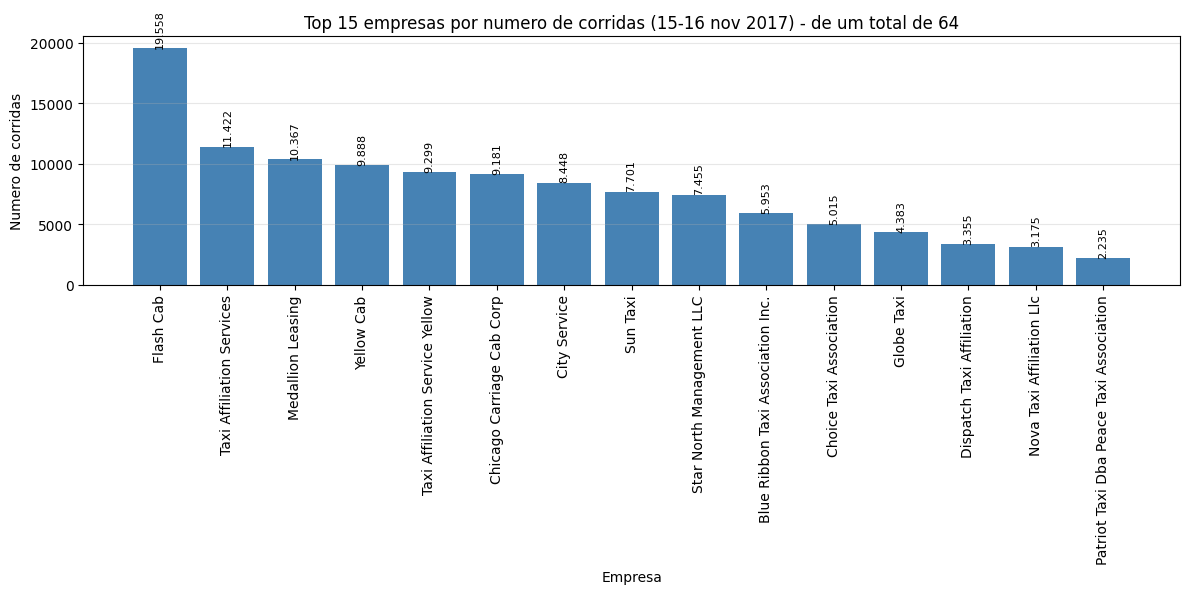

In [ ]:
# 4.4 - Grafico 1: empresas de taxi e numero de corridas

top15_emp = df_companies.sort_values('trips_amount', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top15_emp['company_name'], top15_emp['trips_amount'], color='steelblue')
ax.set_title('Top 15 empresas por numero de corridas (15-16 nov 2017) - de um total de ' + str(len(df_companies)))
ax.set_xlabel('Empresa')
ax.set_ylabel('Numero de corridas')
ax.tick_params(axis='x', labelrotation=90)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(top15_emp['trips_amount']):
    ax.text(i, v, format(v, ',').replace(',', '.'), ha='center', va='bottom', fontsize=8, rotation=90)
plt.tight_layout()
plt.show()

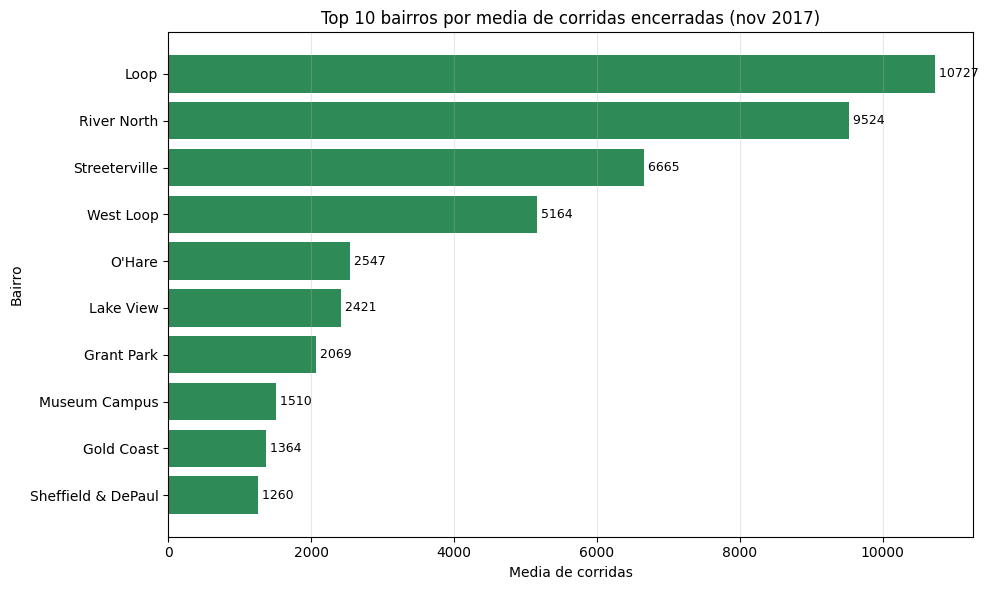

In [ ]:
# 4.5 - Grafico 2: top 10 bairros por numero medio de corridas de destino

ordem = top10.sort_values('average_trips')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ordem['dropoff_location_name'], ordem['average_trips'], color='seagreen')
ax.set_title('Top 10 bairros por media de corridas encerradas (nov 2017)')
ax.set_xlabel('Media de corridas')
ax.set_ylabel('Bairro')
ax.grid(axis='x', alpha=0.3)
for y, v in enumerate(ordem['average_trips']):
    ax.text(v, y, ' ' + str(int(round(v))), va='center', fontsize=9)
plt.tight_layout()
plt.show()

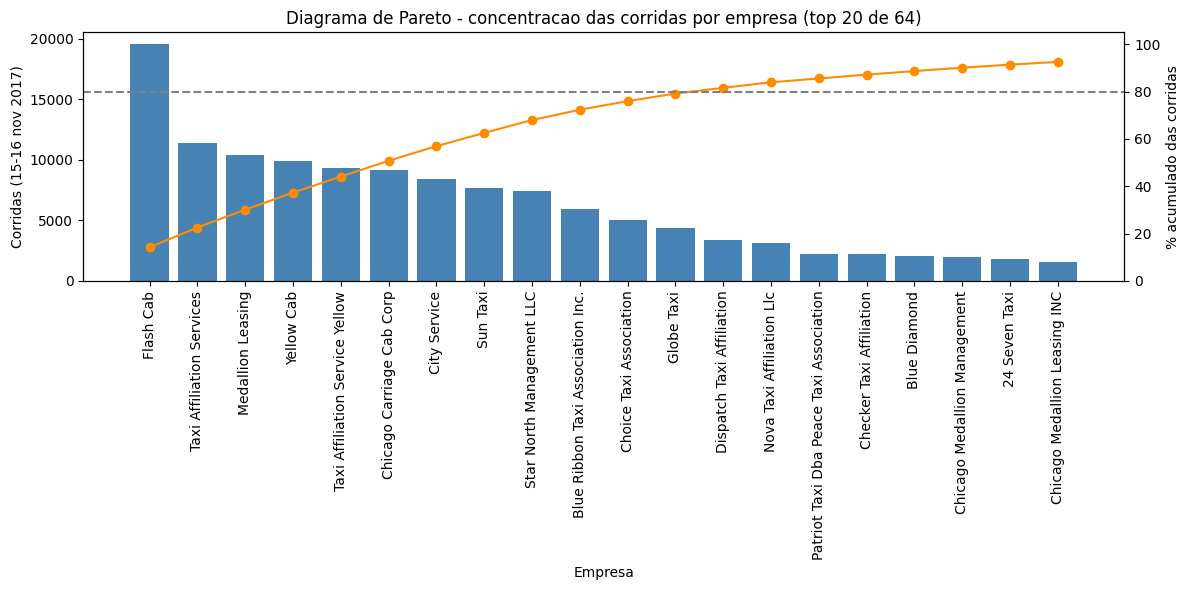

Empresas que respondem por 80% das corridas: 13 de 64
Participacao das 5 maiores: 44.1 %
Empresas com menos de 100 corridas no periodo: 29


In [ ]:
# 4.6 (extra) - Diagrama de Pareto: quanto da demanda esta concentrado em poucas empresas
emp = df_companies.sort_values('trips_amount', ascending=False).reset_index(drop=True)
emp['perc'] = 100 * emp['trips_amount'] / emp['trips_amount'].sum()
emp['acum'] = emp['perc'].cumsum()

top = emp.head(20)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(top['company_name'], top['trips_amount'], color='steelblue')
ax1.set_ylabel('Corridas (15-16 nov 2017)')
ax1.set_xlabel('Empresa')
ax1.tick_params(axis='x', labelrotation=90)

ax2 = ax1.twinx()
ax2.plot(top['company_name'], top['acum'], color='darkorange', marker='o')
ax2.axhline(80, color='gray', linestyle='--')
ax2.set_ylabel('% acumulado das corridas')
ax2.set_ylim(0, 105)

plt.title('Diagrama de Pareto - concentracao das corridas por empresa (top 20 de ' + str(len(emp)) + ')')
plt.tight_layout()
plt.show()

n80 = int((emp['acum'] < 80).sum()) + 1
print('Empresas que respondem por 80% das corridas:', n80, 'de', len(emp))
print('Participacao das 5 maiores:', round(emp['perc'].head(5).sum(), 1), '%')
print('Empresas com menos de 100 corridas no periodo:', int((emp['trips_amount'] < 100).sum()))

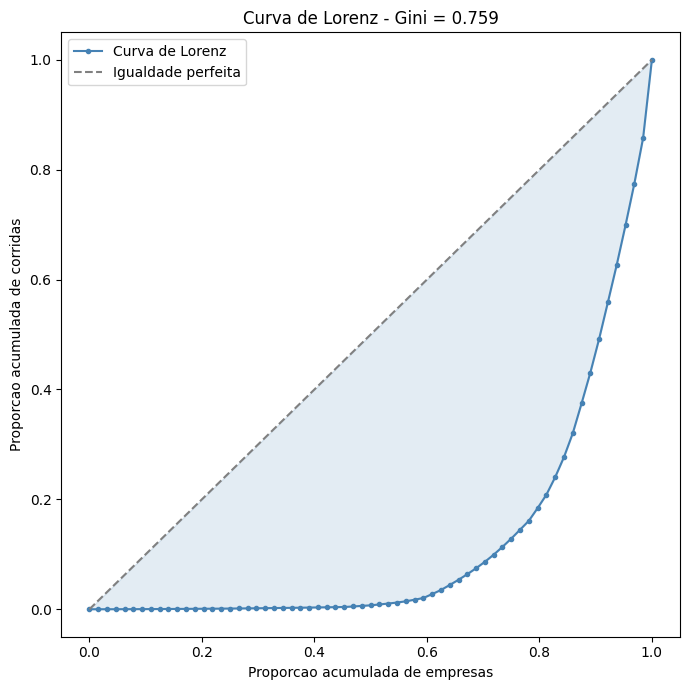

Indice de Gini: 0.759
HHI - indice de Herfindahl-Hirschman: 642
Referencia: HHI abaixo de 1500 indica mercado pouco concentrado; entre 1500 e 2500, moderadamente concentrado.


In [ ]:
# 4.7 (extra) - Curva de Lorenz, indice de Gini e HHI
v = np.sort(df_companies['trips_amount'].to_numpy())
n = len(v)

lorenz = np.insert(np.cumsum(v) / v.sum(), 0, 0)
x = np.linspace(0, 1, n + 1)

gini = 1 - (lorenz[:-1] + lorenz[1:]).sum() / n
hhi = ((100 * v / v.sum()) ** 2).sum()

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, lorenz, marker='.', color='steelblue', label='Curva de Lorenz')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Igualdade perfeita')
ax.fill_between(x, lorenz, x, color='steelblue', alpha=0.15)
ax.set_xlabel('Proporcao acumulada de empresas')
ax.set_ylabel('Proporcao acumulada de corridas')
ax.set_title('Curva de Lorenz - Gini = ' + str(round(gini, 3)))
ax.legend()
plt.tight_layout()
plt.show()

print('Indice de Gini:', round(gini, 3))
print('HHI - indice de Herfindahl-Hirschman:', round(hhi))
print('Referencia: HHI abaixo de 1500 indica mercado pouco concentrado; entre 1500 e 2500, moderadamente concentrado.')

In [ ]:
# 4.8 (extra) - Varios nomes parecem pertencer ao mesmo grupo.

def grupo_economico(nome):
    n = nome.lower()
    if 'flash cab' in n:
        return 'Flash Cab (grupo)'
    if 'taxi affiliation' in n:
        return 'Taxi Affiliation (grupo)'
    if 'medallion' in n:
        return 'Medallion (grupo)'
    return nome

emp_grupo = df_companies.copy()
emp_grupo['grupo'] = emp_grupo['company_name'].apply(grupo_economico)

agrupado = (emp_grupo.groupby('grupo')['trips_amount']
            .agg(['sum', 'count'])
            .rename(columns={'sum': 'trips_amount', 'count': 'marcas'})
            .sort_values('trips_amount', ascending=False))
agrupado['perc'] = (100 * agrupado['trips_amount'] / agrupado['trips_amount'].sum()).round(2)

print('Top 10 grupos economicos:')
print(agrupado.head(10))
print()

vg = agrupado['trips_amount'].to_numpy()
hhi_grupo = ((100 * vg / vg.sum()) ** 2).sum()

print('Marcas antes do agrupamento:', len(df_companies), '| grupos depois:', len(agrupado))
print('Participacao das 5 maiores - por marca:', round(emp['perc'].head(5).sum(), 1), '%')
print('Participacao das 5 maiores - por grupo:', round(agrupado['perc'].head(5).sum(), 1), '%')
print('HHI por marca:', round(hhi), '| HHI por grupo:', round(hhi_grupo))

Top 10 grupos economicos:
                                   trips_amount  marcas   perc
grupo                                                         
Taxi Affiliation (grupo)                  29677       6  21.61
Flash Cab (grupo)                         19558       1  14.24
Medallion (grupo)                         13929       3  10.14
Yellow Cab                                 9888       1   7.20
Chicago Carriage Cab Corp                  9181       1   6.69
City Service                               8448       1   6.15
Sun Taxi                                   7701       1   5.61
Star North Management LLC                  7455       1   5.43
Blue Ribbon Taxi Association Inc.          5953       1   4.34
Choice Taxi Association                    5015       1   3.65

Marcas antes do agrupamento: 64 | grupos depois: 57
Participacao das 5 maiores - por marca: 44.1 %
Participacao das 5 maiores - por grupo: 59.9 %
HHI por marca: 642 | HHI por grupo: 1023


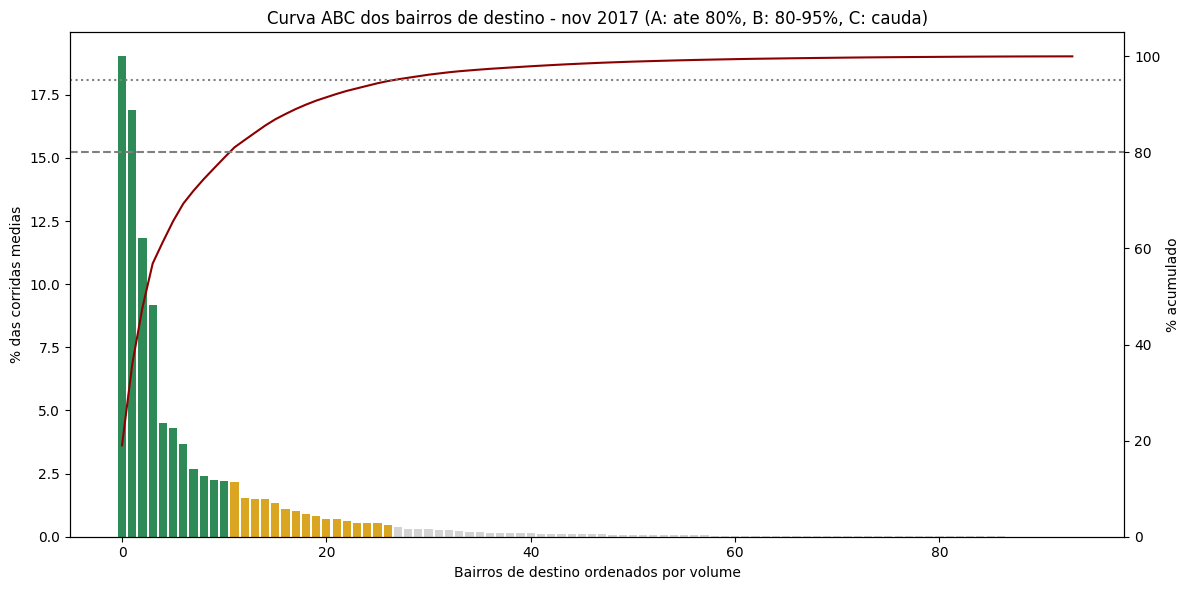

A    11
B    16
C    67
Name: classe, dtype: int64

Bairros classe A: Loop, River North, Streeterville, West Loop, O'Hare, Lake View, Grant Park, Museum Campus, Gold Coast, Sheffield & DePaul, Lincoln Park


In [ ]:
# 4.9 (extra) - Curva ABC dos bairros de destino (preferencia dos passageiros)
abc = df_dropoff.sort_values('average_trips', ascending=False).reset_index(drop=True)
abc['perc'] = 100 * abc['average_trips'] / abc['average_trips'].sum()
abc['acum'] = abc['perc'].cumsum()
abc['classe'] = np.where(abc['acum'] <= 80, 'A', np.where(abc['acum'] <= 95, 'B', 'C'))

cores_abc = abc['classe'].map({'A': 'seagreen', 'B': 'goldenrod', 'C': 'lightgray'})

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(range(len(abc)), abc['perc'], color=cores_abc)
ax1.set_xlabel('Bairros de destino ordenados por volume')
ax1.set_ylabel('% das corridas medias')

ax2 = ax1.twinx()
ax2.plot(range(len(abc)), abc['acum'], color='darkred')
ax2.axhline(80, color='gray', linestyle='--')
ax2.axhline(95, color='gray', linestyle=':')
ax2.set_ylabel('% acumulado')
ax2.set_ylim(0, 105)

plt.title('Curva ABC dos bairros de destino - nov 2017 (A: ate 80%, B: 80-95%, C: cauda)')
plt.tight_layout()
plt.show()

print(abc['classe'].value_counts().sort_index())
print()
print('Bairros classe A:', ', '.join(abc.loc[abc['classe'] == 'A', 'dropoff_location_name']))

### Conclusões do Passo 4

**Qualidade dos dados.** 

Não encontrei valores ausentes, linhas duplicadas nem nomes repetidos, então não precisei limpar nada. Só vale lembrar que as duas bases cobrem janelas diferentes — dois dias úteis (15 e 16/11) no arquivo de empresas e o mês inteiro no de bairros —, então os números de uma não podem ser comparados com os da outra.

**Empresas de táxi.** O gráfico deixa clara uma distribuição bem desigual. A Flash Cab lidera com 19.558 corridas, seguida por Taxi Affiliation Services (11.422), Medallion Leasing (10.367) e Yellow Cab (9.888). Depois disso o volume despenca: 29 das 64 empresas fizeram menos de 100 corridas em dois dias. O Pareto confirma a leitura — 13 empresas concentram 80% das corridas e as 5 maiores ficam com 44,1%. O Gini de 0,759 e a curva de Lorenz bem afastada da diagonal apontam para o mesmo lado.

O HHI por marca, porém, deu 642, bem abaixo de 1.500, o que sugeriria um mercado pouco concentrado. Isso acontece porque várias marcas são do mesmo grupo (as "Taxi Affiliation", as três "Medallion"). Juntando só os casos óbvios, a participação das 5 maiores sobe de 44,1% para 59,9% e o HHI vai para 1.023, com o grupo Taxi Affiliation sozinho respondendo por 21,6% do mercado. Ou seja: a concorrência é mais concentrada do que a lista de nomes faz parecer, mas ainda não existe um dominante absoluto.

**Bairros de destino.** O topo do ranking é Loop (10.727), River North (9.524), Streeterville (6.665) e West Loop (5.164). Do quinto lugar em diante (O'Hare, com 2.547) os valores caem bastante. Esses 10 bairros já representam 76,7% do total, e a curva ABC mostra 11 bairros na classe A contra 67 na cauda. São exatamente as áreas centrais e de negócios da cidade, mais o aeroporto — escritórios, comércio, turismo e vida noturna puxam a demanda.

**Resumo do passo.** A demanda é concentrada dos dois lados: poucas empresas realizam a maior parte das corridas e poucos bairros recebem a maior parte das viagens. Para a Zuber, isso indica começar pelo centro e pelo corredor do aeroporto, ficando de olho na Flash Cab e no grupo Taxi Affiliation.

## Passo 5 — Teste de hipótese

**Hipótese a testar:** "A duração média das corridas do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos."

In [ ]:
# 5.1 - Carregar os dados e VALIDAR o recorte da amostra
df = pd.read_csv('/datasets/project_sql_result_07.csv')
df['start_ts'] = pd.to_datetime(df['start_ts'])

df.info()
print(df.head())
print()

# conferindo se a amostra e mesmo so de sabados
dias = sorted(df['start_ts'].dt.dayofweek.unique())
print('Dias da semana presentes (0=segunda ... 5=sabado, 6=domingo):', dias)
print('Todos os registros sao de sabado?', dias == [5])
print('Datas distintas na amostra:', df['start_ts'].dt.date.nunique())
print('Periodo coberto:', df['start_ts'].min(), 'ate', df['start_ts'].max())
print('Categorias de clima:', list(df['weather_conditions'].unique()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
             start_ts weather_conditions  duration_seconds
0 2017-11-25 16:00:00               Good            2410.0
1 2017-11-25 14:00:00               Good            1920.0
2 2017-11-25 12:00:00               Good            1543.0
3 2017-11-04 10:00:00               Good            2512.0
4 2017-11-11 07:00:00               Good            1440.0

Dias da semana presentes (0=segunda ... 5=sabado, 6=domingo): [5]
Todos os registros sao de sabado? True
Datas distintas na amostra: 4
Periodo coberto: 2017-11-04 00:00:00 ate 2017-11-25 

In [ ]:
# 5.2 - Qualidade dos dados e valores extremos
print('valores ausentes por coluna:')
print(df.isna().sum())
print()

print('linhas identicas:', int(df.duplicated().sum()))
# linhas repetidas aqui nao sao erro: a base nao tem trip_id, entao corridas diferentes podem coincidir
print('Horas distintas na base:', df['start_ts'].nunique(), '| total de corridas:', len(df))
print()

zeros = df[df['duration_seconds'] == 0]
print('duracao minima (s):', df['duration_seconds'].min(), '| maxima (s):', df['duration_seconds'].max())
print('corridas com duracao igual a zero:', len(zeros))
print(zeros)
print()

q1 = df['duration_seconds'].quantile(0.25)
q3 = df['duration_seconds'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
outliers = df[(df['duration_seconds'] < lim_inf) | (df['duration_seconds'] > lim_sup)]

print('Limites pelo criterio do IQR:', round(lim_inf, 1), 'a', round(lim_sup, 1), 'segundos')
print('Corridas fora desses limites:', len(outliers), '(', round(100 * len(outliers) / len(df), 1), '% da amostra )')
print(outliers['weather_conditions'].value_counts())
print()

valores ausentes por coluna:
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

linhas identicas: 197
Horas distintas na base: 81 | total de corridas: 1068

duracao minima (s): 0.0 | maxima (s): 7440.0
corridas com duracao igual a zero: 6
                start_ts weather_conditions  duration_seconds
163  2017-11-11 09:00:00               Good               0.0
168  2017-11-11 07:00:00               Good               0.0
204  2017-11-18 19:00:00               Good               0.0
552  2017-11-04 01:00:00               Good               0.0
801  2017-11-04 09:00:00               Good               0.0
1063 2017-11-25 11:00:00               Good               0.0

Limites pelo criterio do IQR: -274.4 a 4292.6 segundos
Corridas fora desses limites: 6 ( 0.6 % da amostra )
Good    5
Bad     1
Name: weather_conditions, dtype: int64



                    count    mean  median    std    min     max
weather_conditions                                             
Bad                   180  2427.2  2540.0  721.3  480.0  4980.0
Good                  888  1999.7  1800.0  759.2    0.0  7440.0

Diferenca das medias (Bad - Good): 427.5 segundos = 7.13 minutos


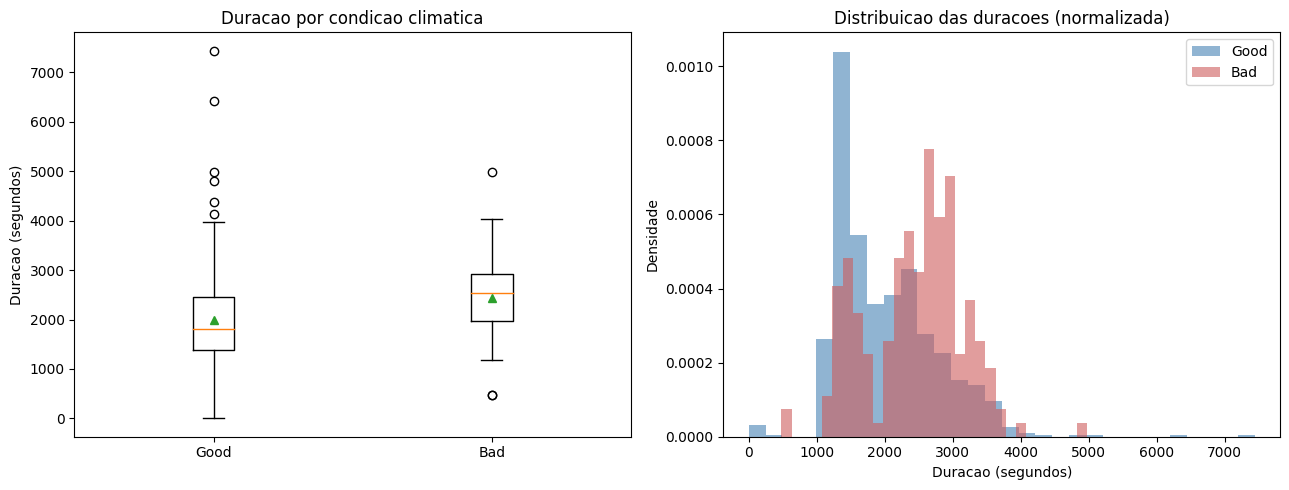

In [ ]:
# 5.3 - Estatisticas descritivas por grupo e visualizacao das distribuicoes
good = df[df['weather_conditions'] == 'Good']['duration_seconds']
bad = df[df['weather_conditions'] == 'Bad']['duration_seconds']

resumo = df.groupby('weather_conditions')['duration_seconds'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(1)
print(resumo)
print()
print('Diferenca das medias (Bad - Good):', round(bad.mean() - good.mean(), 1), 'segundos =',
      round((bad.mean() - good.mean()) / 60, 2), 'minutos')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot([good.to_numpy(), bad.to_numpy()], showmeans=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['Good', 'Bad'])
axes[0].set_title('Duracao por condicao climatica')
axes[0].set_ylabel('Duracao (segundos)')

axes[1].hist(good, bins=30, alpha=0.6, label='Good', color='steelblue', density=True)
axes[1].hist(bad, bins=30, alpha=0.6, label='Bad', color='indianred', density=True)
axes[1].set_title('Distribuicao das duracoes (normalizada)')
axes[1].set_xlabel('Duracao (segundos)')
axes[1].set_ylabel('Densidade')
axes[1].legend()

plt.tight_layout()
plt.show()

Levene (igualdade de variancias): estatistica = 0.389 | valor-p = 0.5332
  -> nao ha evidencia de variancias diferentes, mas o Welch continua sendo a escolha mais segura.

Shapiro-Wilk Good : valor-p = 0.0 | assimetria = 1.169
Shapiro-Wilk Bad : valor-p = 0.003612 | assimetria = -0.091

As distribuicoes nao sao perfeitamente normais, mas com n = 888 e n = 180 o Teorema Central do Limite garante que a media amostral se aproxima da normal.


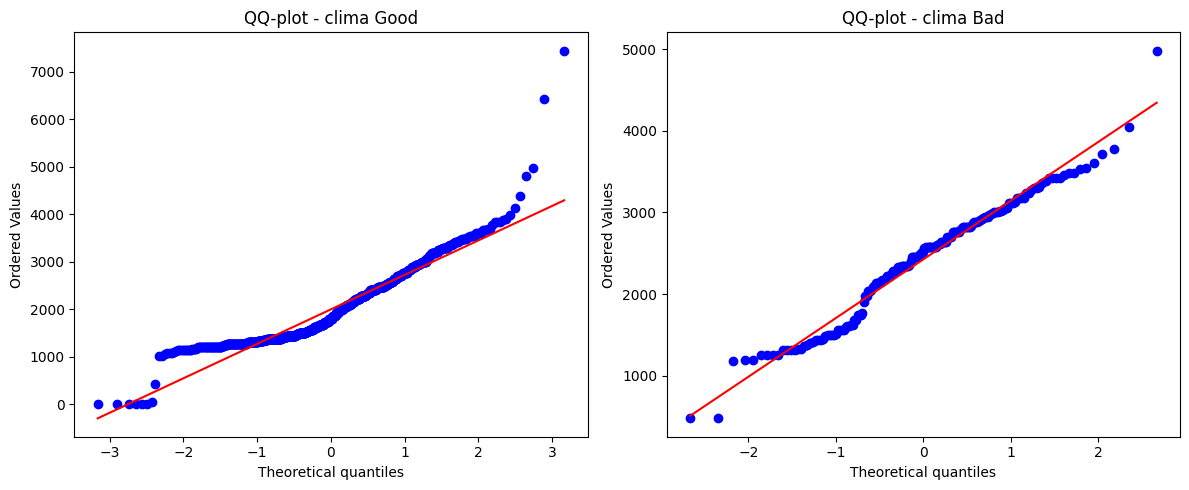

In [ ]:
# 5.4 - Diagnostico dos pressupostos do teste t

stat_lev, p_lev = stats.levene(good, bad)
print('Levene (igualdade de variancias): estatistica =', round(stat_lev, 3), '| valor-p =', round(p_lev, 4))
if p_lev < 0.05:
    print('  -> variancias diferentes: o teste de Welch (equal_var=False) e o mais adequado.')
else:
    print('  -> nao ha evidencia de variancias diferentes, mas o Welch continua sendo a escolha mais segura.')
print()

for nome, amostra in [('Good', good), ('Bad', bad)]:
    w, p_sw = stats.shapiro(amostra)
    print('Shapiro-Wilk', nome, ': valor-p =', round(p_sw, 6), '| assimetria =', round(stats.skew(amostra), 3))
print()
print('As distribuicoes nao sao perfeitamente normais, mas com n =', len(good), 'e n =', len(bad),
      'o Teorema Central do Limite garante que a media amostral se aproxima da normal.')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(good, dist='norm', plot=axes[0])
axes[0].set_title('QQ-plot - clima Good')
stats.probplot(bad, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot - clima Bad')
plt.tight_layout()
plt.show()

In [ ]:
# 5.5 - Teste da hipotese


alpha = 0.05

res_t = stats.ttest_ind(bad, good, equal_var=False)
print('Teste t de Welch  -> estatistica =', round(res_t.statistic, 3), '| valor-p =', res_t.pvalue)

res_u = stats.mannwhitneyu(bad, good, alternative='two-sided')
print('Mann-Whitney U    -> estatistica =', res_u.statistic, '| valor-p =', res_u.pvalue)
print()

# Tamanho do efeito e intervalo de confianca: o valor-p diz SE ha diferenca, nao QUANTO ela vale.
n1, n2 = len(bad), len(good)
m1, m2 = bad.mean(), good.mean()
s1, s2 = bad.std(ddof=1), good.std(ddof=1)

dif = m1 - m2
erro_padrao = np.sqrt(s1**2 / n1 + s2**2 / n2)
gl = (s1**2 / n1 + s2**2 / n2)**2 / ((s1**2 / n1)**2 / (n1 - 1) + (s2**2 / n2)**2 / (n2 - 1))
t_critico = stats.t.ppf(1 - alpha / 2, gl)
ic_inf = dif - t_critico * erro_padrao
ic_sup = dif + t_critico * erro_padrao

s_pool = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohen_d = dif / s_pool

print('Diferenca das medias (Bad - Good):', round(dif, 1), 's  (', round(dif / 60, 2), 'min )')
print('IC 95% da diferenca:', round(ic_inf, 1), 'a', round(ic_sup, 1), 's  (',
      round(ic_inf / 60, 2), 'a', round(ic_sup / 60, 2), 'min )')
print('d de Cohen:', round(cohen_d, 3), '- efeito', 'pequeno' if abs(cohen_d) < 0.5 else ('medio' if abs(cohen_d) < 0.8 else 'grande'))
print()

if res_t.pvalue < alpha:
    print('Valor-p menor que alpha =', alpha, '-> REJEITAMOS a hipotese nula.')
    print('Ha evidencia estatistica de que a duracao media muda em sabados chuvosos.')
else:
    print('Valor-p maior ou igual a alpha =', alpha, '-> NAO rejeitamos a hipotese nula.')

# Analise de sensibilidade: o resultado depende das corridas com duracao zero?
sem_zero = df[df['duration_seconds'] > 0]
g_sz = sem_zero[sem_zero['weather_conditions'] == 'Good']['duration_seconds']
b_sz = sem_zero[sem_zero['weather_conditions'] == 'Bad']['duration_seconds']
res_sz = stats.ttest_ind(b_sz, g_sz, equal_var=False)

print()
print('Sensibilidade - excluindo as', len(df) - len(sem_zero), 'corridas de duracao zero:')
print('  diferenca das medias:', round(b_sz.mean() - g_sz.mean(), 1), 's | valor-p =', res_sz.pvalue)

Teste t de Welch  -> estatistica = 7.186 | valor-p = 6.738994326108734e-12
Mann-Whitney U    -> estatistica = 108193.5 | valor-p = 6.716538885593458e-14

Diferenca das medias (Bad - Good): 427.5 s  ( 7.13 min )
IC 95% da diferenca: 310.4 a 544.7 s  ( 5.17 a 9.08 min )
d de Cohen: 0.568 - efeito medio

Valor-p menor que alpha = 0.05 -> REJEITAMOS a hipotese nula.
Ha evidencia estatistica de que a duracao media muda em sabados chuvosos.

Sensibilidade - excluindo as 6 corridas de duracao zero:
  diferenca das medias: 413.9 s | valor-p = 2.4173590471585584e-11


Distribuicao do horario de inicio por condicao climatica:
                    count  mean  std  min   25%   50%   75%   max
weather_conditions                                               
Bad                 180.0  13.6  3.7  0.0  10.0  16.0  16.2  21.0
Good                888.0  11.0  4.0  0.0   8.0  11.0  14.0  23.0

Duracao media e numero de corridas por hora:
                      mean         count       
weather_conditions     Bad    Good   Bad   Good
hora                                           
0                    480.0  1560.0   1.0    1.0
1                      NaN     0.0   NaN    1.0
2                      NaN  2956.0   NaN    1.0
3                      NaN  1250.0   NaN    4.0
4                      NaN  1362.0   NaN   20.0
5                      NaN  1403.0   NaN   36.0
6                      NaN  1452.0   NaN   96.0
7                   1402.0  1331.0  12.0   51.0
8                   1464.0  1393.0  17.0   71.0
9                   1378.0  1426.0   2.0   40.0
10      

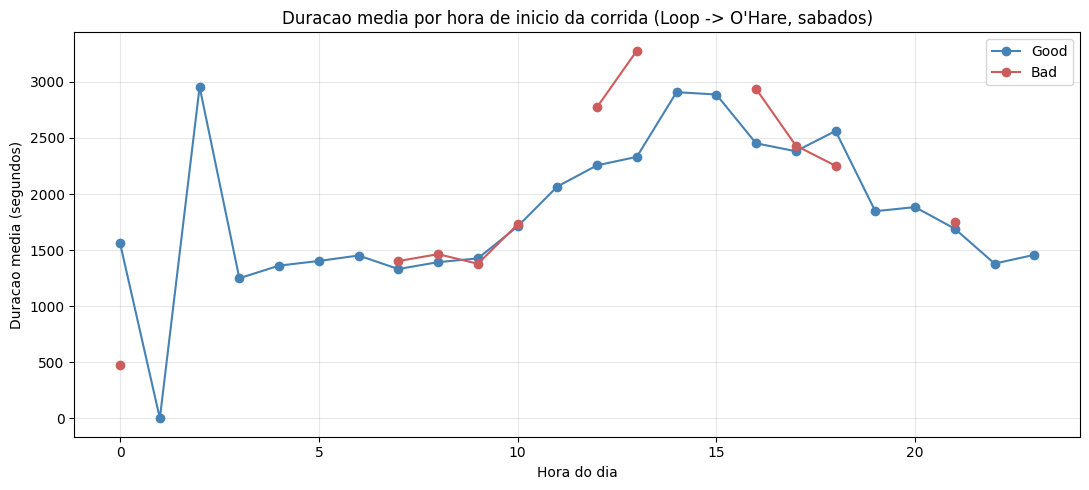


Restringindo o horario a faixa das 8h as 20h (n Bad = 166 , n Good = 671 ):
  diferenca das medias: 326.2 s | valor-p = 1.1496839604207636e-07


In [ ]:
# 5.6 - Checando se o horario do dia nao explica sozinho a diferenca

df['hora'] = df['start_ts'].dt.hour

print('Distribuicao do horario de inicio por condicao climatica:')
print(df.groupby('weather_conditions')['hora'].describe().round(1))
print()

tabela = df.pivot_table(index='hora', columns='weather_conditions',
                        values='duration_seconds', aggfunc=['mean', 'count'])
print('Duracao media e numero de corridas por hora:')
print(tabela.round(0))

media_hora = df.pivot_table(index='hora', columns='weather_conditions', values='duration_seconds', aggfunc='mean')

fig, ax = plt.subplots(figsize=(11, 5))
if 'Good' in media_hora.columns:
    ax.plot(media_hora.index, media_hora['Good'], marker='o', color='steelblue', label='Good')
if 'Bad' in media_hora.columns:
    ax.plot(media_hora.index, media_hora['Bad'], marker='o', color='indianred', label='Bad')
ax.set_title('Duracao media por hora de inicio da corrida (Loop -> O\'Hare, sabados)')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Duracao media (segundos)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Comparacao dentro da faixa de horario com mais dados nos dois grupos
faixa = df[(df['hora'] >= 8) & (df['hora'] <= 20)]
g2 = faixa[faixa['weather_conditions'] == 'Good']['duration_seconds']
b2 = faixa[faixa['weather_conditions'] == 'Bad']['duration_seconds']
res2 = stats.ttest_ind(b2, g2, equal_var=False)
print()
print('Restringindo o horario a faixa das 8h as 20h (n Bad =', len(b2), ', n Good =', len(g2), '):')
print('  diferenca das medias:', round(b2.mean() - g2.mean(), 1), 's | valor-p =', res2.pvalue)

### Conclusões do Passo 5

**Como formulei as hipóteses.**

Parti do que o enunciado afirma — que a duração média das corridas do Loop para o O'Hare muda nos sábados chuvosos — e transformei isso no par de hipóteses. A nula é a versão conservadora, a de que nada acontece: a duração média aos sábados é igual com e sem chuva. A alternativa é o contrário, a de que as duas médias são diferentes. Não indiquei direção porque a pergunta fala em "mudar", e não em "aumentar", então mesmo esperando que a chuva atrasasse o percurso preferi não embutir essa expectativa no teste. Por isso ele é bicaudal. Fixei o alfa em 0,05 antes de rodar qualquer coisa, para não acabar escolhendo o limite depois de já conhecer o resultado.

**A escolha do teste.**

Usei o teste t de Welch (`ttest_ind` com `equal_var=False`) porque estou comparando as médias de duas amostras independentes, as corridas com chuva e as corridas sem chuva, e nada liga uma observação de um grupo a outra do outro. O Levene deu p = 0,53, ou seja, não encontrei evidência de variâncias diferentes, mas mantive o Welch por ser a opção mais segura quando os grupos têm tamanhos bem desiguais. O Shapiro-Wilk rejeita a normalidade nos dois grupos (o "Good" tem assimetria de 1,17), só que com n = 888 e n = 180 o Teorema Central do Limite resolve isso. Ainda assim rodei o Mann-Whitney como conferência, e ele chegou à mesma conclusão (p ≈ 6,7 × 10⁻¹⁴).

**O que a amostra contém.**

As 1.068 corridas são todas de sábado e estão distribuídas nos quatro sábados de novembro de 2017, então a comparação entre "Bad" e "Good" é mesmo entre sábados chuvosos e sábados sem chuva. As 197 linhas repetidas me chamaram atenção no começo, mas não são erro: a consulta exportou apenas hora, clima e duração, sem o `trip_id`, então duas corridas diferentes na mesma hora e com a mesma duração acabam virando linhas iguais, e apagá-las seria perder observação legítima. Já as 6 corridas com duração zero são implausíveis, só que removê-las quase não muda nada — a diferença cai de 427,5 s para 413,9 s e o valor-p continua na casa de 10⁻¹¹ —, então preferi mantê-las e deixar a checagem registrada.

**O resultado.**

O valor-p do Welch foi 6,7 × 10⁻¹², bem abaixo do alfa que defini, então rejeito a hipótese nula. Como o valor-p só diz que existe diferença, fui atrás do tamanho dela:

| Medida | Valor |
| --- | --- |
| Média com chuva ("Bad") | 2.427 s ≈ 40,5 min (n = 180) |
| Média sem chuva ("Good") | 2.000 s ≈ 33,3 min (n = 888) |
| Diferença das médias | **427,5 s ≈ 7,1 min** |
| IC 95% da diferença | 310 a 545 s (5,2 a 9,1 min) |
| d de Cohen | **0,568 — efeito médio** |

Em sábados de chuva a corrida do Loop para o O'Hare demora cerca de 7 minutos a mais. O intervalo de confiança não chega perto do zero e o efeito é de tamanho médio, então não é só significância estatística: a diferença tem tamanho prático.

**Um cuidado com o resultado.**

Olhando o horário, percebi que as corridas com chuva estão concentradas mais tarde no dia (hora média de 13,6 contra 11,0 nas sem chuva), então parte da diferença poderia vir do trânsito e não do clima. Restringindo a comparação à faixa das 8h às 20h, a diferença cai para 326 s mas continua bem significativa (p ≈ 1,1 × 10⁻⁷). O horário explica mais ou menos um quarto do efeito, e o resto fica com o clima.

**Até onde esses dados me deixam ir.**

São apenas quatro sábados, um único trajeto e dados observacionais, então dá para falar em associação, não em causalidade. Além disso, "chuva" aqui é uma variável binária tirada da descrição do tempo, sem intensidade, e a base não traz a distância percorrida, o que me impede de separar rota mais longa de trânsito mais lento.

**O que isso significa para a Zuber.**

Vale somar uns 7 minutos à estimativa do trajeto centro–aeroporto quando estiver chovendo, avisar o passageiro já na cotação e reforçar a oferta de carros nesse corredor em dias de chuva, já que cada corrida ocupa o motorista por mais tempo.

## Conclusão geral

A demanda por táxi em Chicago é concentrada nas duas pontas. Do lado das empresas, 13 das 64 fazem 80% das corridas e as cinco maiores somam 44,1% — ou 59,9% quando agrupo as marcas da mesma família. O HHI sai de 642 para 1.023 nesse agrupamento, o que descreve um mercado desigual, porém ainda sem um dominante absoluto, o que deixa espaço para um entrante como a Zuber. Do lado do destino, 11 dos 94 bairros recebem 80% das viagens, todos no centro ou no eixo do aeroporto: Loop, River North, Streeterville, West Loop e O'Hare.

Sobre o clima, aos sábados as corridas do Loop para o O'Hare duram em média 7,1 minutos a mais quando chove (IC 95%: 5,2 a 9,1 min; valor-p = 6,7 × 10⁻¹²; d de Cohen = 0,568). Mesmo controlando o horário do dia a diferença se mantém, então o clima realmente pesa na duração da viagem. (No **Passo 6** eu volto a esse ponto: quando hora do dia e dia da amostra entram juntos em uma regressão, o efeito isolado da chuva deixa de ser significativo — a diferença bruta vem sobretudo de *quando* as corridas com chuva aconteceram.)

O que eu recomendaria para a Zuber:

1. Concentrar a frota inicial nos bairros da classe A, principalmente no eixo Loop–River North–Streeterville–West Loop e no corredor para o aeroporto.
2. Usar o clima no cálculo do tempo estimado e do preço, começando pelo trajeto centro–aeroporto, onde o efeito já está quantificado.
3. Acompanhar os concorrentes maiores — Flash Cab e grupo Taxi Affiliation —, lembrando que marcas diferentes podem pertencer ao mesmo grupo.

As principais limitações são as janelas curtas de tempo (dois dias para as empresas, quatro sábados para o teste), o clima reduzido a uma variável binária e o caráter observacional da análise. Como próximos passos, valeria estender o período para outros meses e dias da semana, incluir a distância das corridas e modelar a duração com regressão, controlando horário, clima e distância ao mesmo tempo.

## Passo 6 — Cruzamento com a base horária de clima e regressão com controles

Para esse passo, busquei as informações do Passo 1: a página HTML com o clima hora a hora de Chicago em novembro de 2017. Com essa base em mãos, tenho três objetivos:

1. **Validar o `CASE WHEN` do Passo 3** — conferir se a coluna `weather_conditions` do `project_sql_result_07.csv` corresponde mesmo às descrições meteorológicas da hora de início de cada corrida.
2. **Usar a temperatura como variável contínua**, e não apenas o rótulo binário Good/Bad.
3. **Isolar o efeito da chuva** com regressão, controlando hora do dia e dia da amostra ao mesmo tempo.

In [ ]:
# 6.1 (extra) - Base horaria de clima do Passo 1 cruzada com as corridas
import requests
from bs4 import BeautifulSoup

URL_CLIMA = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html'
soup = BeautifulSoup(requests.get(URL_CLIMA).text, 'html.parser')

linhas = []
for tr in soup.find('table').find_all('tr'):
    celulas = [td.get_text(strip=True) for td in tr.find_all('td')]
    if celulas:
        linhas.append(celulas)

clima = pd.DataFrame(linhas, columns=['ts', 'temperatura', 'descricao'])
clima['ts'] = pd.to_datetime(clima['ts'])
clima['temp_c'] = clima['temperatura'].astype(float) - 273.15   # a pagina traz a temperatura em KELVIN
clima['ruim'] = clima['descricao'].str.contains('rain|storm', case=False).astype(int)
clima = clima[['ts', 'temp_c', 'descricao', 'ruim']].sort_values('ts').reset_index(drop=True)

horas_esperadas = int((clima['ts'].max() - clima['ts'].min()) / pd.Timedelta('1h')) + 1
print('Registros horarios lidos:', len(clima), '| esperados no periodo:', horas_esperadas, '| faltando:', horas_esperadas - len(clima))
print('Periodo coberto:', clima['ts'].min(), 'a', clima['ts'].max())
print('Temperatura (C): min', round(clima['temp_c'].min(), 1), '| media', round(clima['temp_c'].mean(), 1), '| max', round(clima['temp_c'].max(), 1))
print('Horas com chuva ou tempestade:', clima['ruim'].sum(), '(', round(100 * clima['ruim'].mean(), 1), '% das horas de novembro )')
print()
print('Descricoes mais frequentes:')
print(clima['descricao'].value_counts().head(8))

Registros horarios lidos: 697 | esperados no periodo: 697 | faltando: 0
Periodo coberto: 2017-11-01 00:00:00 a 2017-11-30 00:00:00
Temperatura (C): min -7.4 | media 4.4 | max 16.6
Horas com chuva ou tempestade: 54 ( 7.7 % das horas de novembro )

Descricoes mais frequentes:
sky is clear        178
overcast clouds     146
mist                 97
broken clouds        63
scattered clouds     47
few clouds           37
light rain           31
fog                  24
Name: descricao, dtype: int64


In [ ]:
# 6.2 (extra) - Validando o CASE WHEN do Passo 3 contra a base horaria de clima


corridas = df.copy()
corridas['hora_cheia'] = corridas['start_ts'].dt.floor('h')

corridas = corridas.merge(clima, left_on='hora_cheia', right_on='ts', how='left')
print('Corridas sem hora correspondente na base de clima:', int(corridas['ts'].isna().sum()), 'de', len(corridas))
print()

corridas['clima_recalc'] = np.where(corridas['ruim'] == 1, 'Bad', 'Good')

print('Rotulo do SQL (linhas) x rotulo recalculado pelo HTML (colunas):')
print(pd.crosstab(corridas['weather_conditions'], corridas['clima_recalc']))
print()

acordo = (corridas['weather_conditions'] == corridas['clima_recalc']).mean()
print('Concordancia entre os dois rotulos:', round(100 * acordo, 2), '%')

divergentes = corridas[corridas['weather_conditions'] != corridas['clima_recalc']]
print('Corridas divergentes:', len(divergentes))
if len(divergentes) > 0:
    print(divergentes[['start_ts', 'weather_conditions', 'descricao', 'duration_seconds']].head(10))
print()
print('Descricoes de clima presentes nas horas da amostra, por rotulo do SQL:')
print(corridas.groupby('weather_conditions')['descricao'].value_counts())

Corridas sem hora correspondente na base de clima: 0 de 1068

Rotulo do SQL (linhas) x rotulo recalculado pelo HTML (colunas):
clima_recalc        Bad  Good
weather_conditions           
Bad                 180     0
Good                  0   888

Concordancia entre os dois rotulos: 100.0 %
Corridas divergentes: 0

Descricoes de clima presentes nas horas da amostra, por rotulo do SQL:
weather_conditions  descricao                       
Bad                 thunderstorm with drizzle            39
                    light rain                           37
                    proximity thunderstorm               34
                    moderate rain                        27
                    heavy intensity rain                 26
                    proximity thunderstorm with rain     14
                    thunderstorm with rain                3
Good                sky is clear                        377
                    mist                                142
                   

Temperatura (C) por condicao climatica:
                    count  mean  std  min  25%  50%  75%   max
weather_conditions                                            
Bad                 180.0   7.3  0.9  3.3  6.6  7.3  7.9   8.3
Good                888.0   2.2  5.0 -3.6 -3.3  5.2  6.7  12.2

Pearson  temperatura x duracao: 0.308 | valor-p = 0.0
Spearman temperatura x duracao: 0.336 | valor-p = 0.0

Duracao por faixa de temperatura (quartis da amostra):
                 count    mean  median
temp_c                                
(-3.601, -3.27]    291  1543.5  1440.0
(-3.27, 6.26]      255  2010.5  2040.0
(6.26, 7.0]        259  2709.1  2825.0
(7.0, 12.22]       263  2087.9  2120.0

Proporcao de corridas com chuva em cada faixa de temperatura:
temp_c
(-3.601, -3.27]    0.00
(-3.27, 6.26]      0.06
(6.26, 7.0]        0.15
(7.0, 12.22]       0.48
Name: ruim, dtype: float64


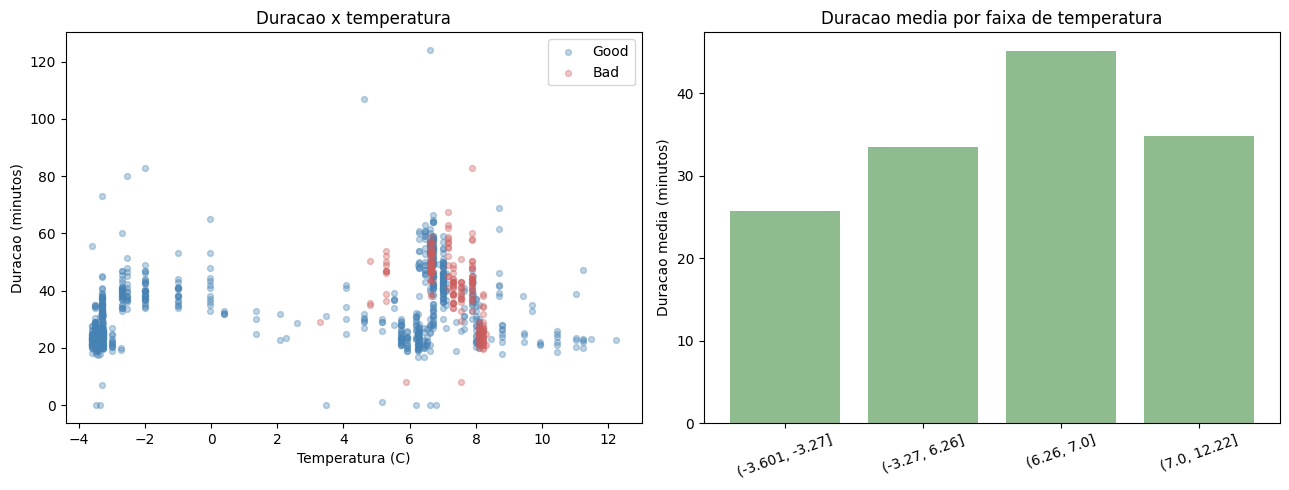

In [ ]:
# 6.3 (extra) - Temperatura como variavel continua, e nao apenas o rotulo Good/Bad
print('Temperatura (C) por condicao climatica:')
print(corridas.groupby('weather_conditions')['temp_c'].describe().round(1))
print()

r_p, p_p = stats.pearsonr(corridas['temp_c'], corridas['duration_seconds'])
r_s, p_s = stats.spearmanr(corridas['temp_c'], corridas['duration_seconds'])
print('Pearson  temperatura x duracao:', round(r_p, 3), '| valor-p =', round(p_p, 6))
print('Spearman temperatura x duracao:', round(r_s, 3), '| valor-p =', round(p_s, 6))
print()

# faixas por quartil da propria amostra, para nao chutar pontos de corte
faixas = pd.qcut(corridas['temp_c'], 4, duplicates='drop')
print('Duracao por faixa de temperatura (quartis da amostra):')
print(corridas.groupby(faixas, observed=False)['duration_seconds'].agg(['count', 'mean', 'median']).round(1))
print()
print('Proporcao de corridas com chuva em cada faixa de temperatura:')
print(corridas.groupby(faixas, observed=False)['ruim'].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for rotulo, cor in [('Good', 'steelblue'), ('Bad', 'indianred')]:
    sub = corridas[corridas['weather_conditions'] == rotulo]
    axes[0].scatter(sub['temp_c'], sub['duration_seconds'] / 60, alpha=0.35, s=18, color=cor, label=rotulo)
axes[0].set_xlabel('Temperatura (C)')
axes[0].set_ylabel('Duracao (minutos)')
axes[0].set_title('Duracao x temperatura')
axes[0].legend()

media_faixa = corridas.groupby(faixas, observed=False)['duration_seconds'].mean() / 60
axes[1].bar([str(i) for i in media_faixa.index], media_faixa.to_numpy(), color='darkseagreen')
axes[1].set_ylabel('Duracao media (minutos)')
axes[1].set_title('Duracao media por faixa de temperatura')
axes[1].tick_params(axis='x', labelrotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# 6.4 (extra) - Regressao para ISOLAR o efeito da chuva
# duracao = b0 + b1*chuva + b2*temperatura + dummies de hora do dia + dummies de data


def ols(y, X, nomes):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    n = len(y)
    XtX_inv = np.linalg.pinv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    resid = y - X @ beta
    rank = np.linalg.matrix_rank(X)
    gl = n - rank
    meat = X.T @ (X * (resid ** 2).reshape(-1, 1))
    cov = XtX_inv @ meat @ XtX_inv
    se = np.sqrt(np.abs(np.diag(cov)))
    t = beta / se
    p = 2 * (1 - stats.t.cdf(np.abs(t), gl))
    r2 = 1 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum()
    tabela = pd.DataFrame({'coef': beta, 'erro_padrao': se, 't': t, 'valor_p': p}, index=nomes)
    return tabela, r2, gl

y = corridas['duration_seconds']
base = pd.DataFrame({'intercepto': np.ones(len(corridas)), 'chuva': corridas['ruim'].astype(float)})
temp = corridas[['temp_c']].astype(float)
dum_hora = pd.get_dummies(corridas['start_ts'].dt.hour, prefix='hora', drop_first=True).astype(float)
dum_data = pd.get_dummies(corridas['start_ts'].dt.date.astype(str), prefix='dia', drop_first=True).astype(float)

modelos = [
    ('M1 - so chuva', base),
    ('M2 - chuva + temperatura', pd.concat([base, temp], axis=1)),
    ('M3 - M2 + hora do dia', pd.concat([base, temp, dum_hora], axis=1)),
    ('M4 - M3 + dia da amostra', pd.concat([base, temp, dum_hora, dum_data], axis=1)),
]

resumo_chuva = []
for nome, X in modelos:
    tab, r2, gl = ols(y, X, list(X.columns))
    principais = [c for c in ['intercepto', 'chuva', 'temp_c'] if c in tab.index]
    print('===', nome, '| n =', len(y), '| variaveis =', X.shape[1], '| R2 =', round(r2, 3))
    print(tab.loc[principais].round(3))
    print()
    resumo_chuva.append({'modelo': nome, 'efeito_chuva_min': tab.loc['chuva', 'coef'] / 60,
                         'valor_p': tab.loc['chuva', 'valor_p'], 'R2': r2})

print('Efeito da chuva sobre a duracao, modelo por modelo:')
print(pd.DataFrame(resumo_chuva).set_index('modelo').round(4))

=== M1 - so chuva | n = 1068 | variaveis = 2 | R2 = 0.043
                coef  erro_padrao       t  valor_p
intercepto  1999.676       25.463  78.534      0.0
chuva        427.530       59.353   7.203      0.0

=== M2 - chuva + temperatura | n = 1068 | variaveis = 3 | R2 = 0.104
                coef  erro_padrao       t  valor_p
intercepto  1908.246       22.410  85.150    0.000
chuva        218.578       67.393   3.243    0.001
temp_c        41.227        4.607   8.950    0.000

=== M3 - M2 + hora do dia | n = 1068 | variaveis = 26 | R2 = 0.62
               coef  erro_padrao       t  valor_p
intercepto  764.988      378.628   2.020    0.044
chuva        45.911       50.266   0.913    0.361
temp_c       34.558        2.980  11.598    0.000

=== M4 - M3 + dia da amostra | n = 1068 | variaveis = 29 | R2 = 0.659
               coef  erro_padrao      t  valor_p
intercepto  422.785      290.740  1.454    0.146
chuva       -91.916       56.291 -1.633    0.103
temp_c      101.525       19.9

In [ ]:
# 6.5 (extra) - O efeito da chuva depende da hora do dia? (termo de interacao)
corridas['pico'] = corridas['start_ts'].dt.hour.between(10, 18).astype(int)

X_int = pd.DataFrame({
    'intercepto': np.ones(len(corridas)),
    'chuva': corridas['ruim'].astype(float),
    'pico': corridas['pico'].astype(float),
    'chuva_x_pico': (corridas['ruim'] * corridas['pico']).astype(float),
    'temp_c': corridas['temp_c'].astype(float),
})
tab_int, r2_int, gl_int = ols(y, X_int, list(X_int.columns))
print('Modelo com interacao chuva x horario de pico (10h-18h) | R2 =', round(r2_int, 3))
print(tab_int.round(3))
print()

print('Duracao media (minutos) por horario e clima:')
print((corridas.pivot_table(index='pico', columns='weather_conditions',
                            values='duration_seconds', aggfunc='mean') / 60).round(2))
print()
print('Numero de corridas por horario e clima:')
print(corridas.pivot_table(index='pico', columns='weather_conditions',
                           values='duration_seconds', aggfunc='count'))

Modelo com interacao chuva x horario de pico (10h-18h) | R2 = 0.453
                  coef  erro_padrao       t  valor_p
intercepto    1363.031       19.006  71.715      0.0
chuva         -254.203       49.865  -5.098      0.0
pico           912.894       34.694  26.313      0.0
chuva_x_pico   357.010       71.720   4.978      0.0
temp_c          38.607        3.568  10.822      0.0

Duracao media (minutos) por horario e clima:
weather_conditions    Bad   Good
pico                            
0                   23.59  23.97
1                   44.24  39.47

Numero de corridas por horario e clima:
weather_conditions  Bad  Good
pico                         
0                    33   352
1                   147   536


### Conclusões do Passo 6 

**A classificação do Passo 3 se confirma (6.2).**

A tabela horária de clima cobriu as 697 horas de novembro de 2017 sem furos, e todas as 1.068 corridas acharam a sua hora de início. O rótulo que recalculei a partir do HTML bateu com o `weather_conditions` do CSV em 100% das corridas (180 Bad e 888 Good, zero divergências), então o `CASE WHEN` do Passo 3 está correto. As descrições classificadas como Bad são `light rain`, `moderate rain`, `heavy intensity rain` e as variações de `thunderstorm`, enquanto `mist` e `fog` ficaram em Good — é uma escolha do enunciado, não um erro, mas convém registrar que neblina também pode atrasar o trânsito.

**Chuva e temperatura andam juntas nesta amostra (6.3).**

Em novembro a temperatura foi de -7,4 °C a 16,6 °C, com média de 4,4 °C. Nos sábados da amostra, as horas de chuva foram justamente as mais quentes: média de 7,3 °C nas corridas Bad contra 2,2 °C nas Good. A correlação entre temperatura e duração é positiva (Pearson 0,308; Spearman 0,336) e a duração média sobe de 25,7 min na faixa mais fria para 45,2 min na faixa de 6,3 a 7,0 °C. Ou seja, o rótulo binário Good/Bad não isola a chuva: ele carrega junto o dia e a temperatura em que a chuva aconteceu.

**Com controles, o efeito da chuva praticamente desaparece (6.4).**

Acompanhei o coeficiente da chuva encolher a cada controle que entrou no modelo:

| Modelo | Efeito da chuva | valor-p | R² |
| --- | --- | --- | --- |
| M1 — só chuva | +7,13 min | < 0,001 | 0,043 |
| M2 — + temperatura | +3,64 min | 0,001 | 0,104 |
| M3 — + hora do dia | +0,77 min | 0,361 | 0,620 |
| M4 — + dia da amostra | -1,53 min | 0,103 | 0,659 |

A diferença bruta de 7,1 minutos do Passo 5 é reproduzida exatamente pelo M1, o que confirma o teste t. Mas o R² salta de 0,04 para 0,62 quando entram as dummies de hora — o horário do dia, e não a chuva, é o que de fato explica a duração. Depois de controlar horário e dia, a chuva deixa de ser significativa ao nível de 5%.

**O efeito da chuva se concentra no pico (6.5).**

No modelo com interação, a chuva fora do horário de pico tem coeficiente negativo (-4,24 min) e no pico o efeito líquido é positivo (-254,2 + 357,0 = +102,8 s, ou +1,7 min). Os números descritivos contam a mesma história: fora do pico a duração média é praticamente igual (23,6 min com chuva contra 24,0 min sem), enquanto no pico a chuva soma quase 5 minutos (44,2 min contra 39,5 min). O horário de pico, por si só, já custa cerca de 15 minutos.

**O que isso muda na leitura do Passo 5.**

O teste do Passo 5 responde corretamente à pergunta do enunciado: a duração média muda nos sábados chuvosos, e a diferença de 7,1 min é real e significativa. O que este passo acrescenta é que essa diferença é uma diferença de médias, e não o efeito causal isolado da chuva — as corridas com chuva se concentraram nos horários de pico e em sábados específicos, e é isso que carrega a maior parte do resultado. Com apenas quatro sábados e 180 corridas com chuva, chuva, horário e dia ficam confundidos e não consigo separá-los com confiança.

**O que eu recomendaria à Zuber.**

Dimensionar a frota primeiro pelo horário, já que o pico das 10h às 18h é o fator dominante e responde por cerca de 15 minutos a mais por corrida, e tratar a chuva como um agravante desse pico, quando ela soma outros cinco minutos. Para transformar isso em previsão confiável seria preciso estender a amostra a outros meses e dias da semana e incluir a distância da corrida, que aqui não está disponível.